# Sales Prediction using Machine Learning

## CodeAlpha Internship Project

This project predicts future sales based on advertising spend, target segment and platform using Machine Learning.

### Objectives:
- Clean and preprocess sales data
- Analyze advertising impact on sales
- Build a regression model
- Predict future sales

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


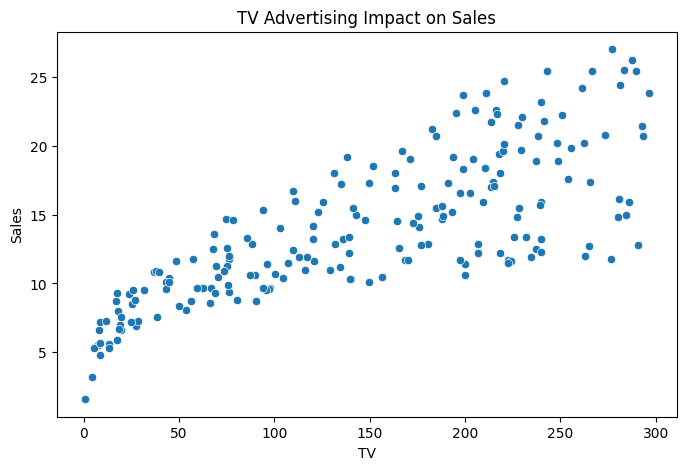

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising Impact on Sales")
plt.show()

In [ ]:
# Selecting input features and target variable

X = df[['TV', 'Radio', 'Newspaper']]

y = df['Sales']

X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

y_pred[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
R2 Score: 0.899438024100912


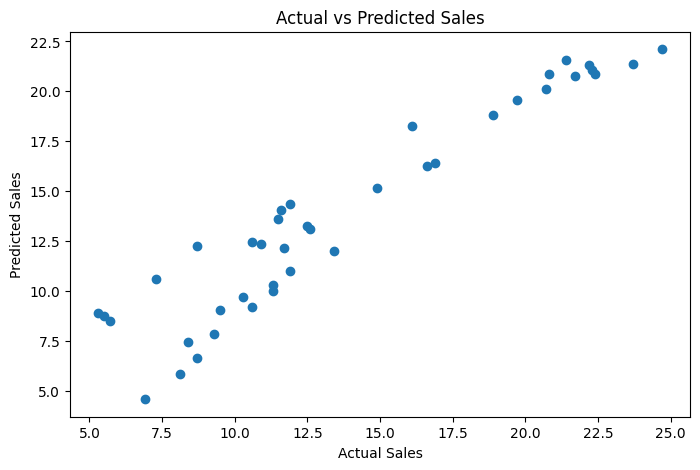

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


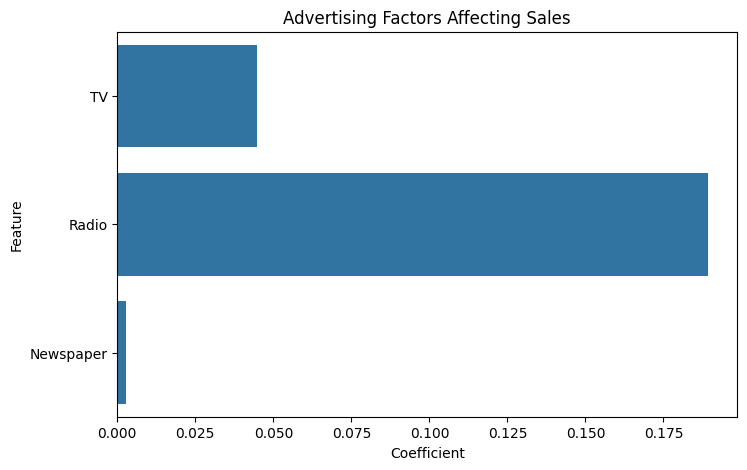

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title("Advertising Factors Affecting Sales")

plt.show()

In [ ]:
new_advertising = pd.DataFrame({
    "TV":[200],
    "Radio":[40],
    "Newspaper":[50]
})

future_prediction = model.predict(new_advertising)

print("Predicted Sales:", future_prediction[0])

Predicted Sales: 19.630828718309314


## Conclusion

The Sales Prediction model was developed using Linear Regression.

The model achieved an R2 score of approximately 90%, showing good prediction accuracy.

Analysis shows that advertising expenditure has a significant effect on sales.

This model can help businesses forecast sales and make better marketing decisions.
